LUẬT KẾT HỢP - APRIORI

1. LOAD DATA ĐÃ XỬ LÝ

In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/data_cleaned.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,-0.024698,0.276380,-0.087788,0.133760,1.318170,1.731801,-1.220488,1.379017,-1.312414,0
1,0.849411,0.958501,-0.199087,1.531834,-0.019184,-0.090093,0.796898,-0.001966,-1.190445,0
2,1.028484,0.610743,0.067098,0.670947,0.879328,-0.782072,1.284355,2.275289,0.876799,0
3,1.666523,-0.562404,-0.442764,-0.399530,-0.884687,-0.342620,-0.854093,-2.312822,0.149055,0
4,-1.219937,-0.308120,0.916600,0.306890,-0.260491,-1.817403,-1.836085,-0.774144,-1.842654,0


2. RỜI RẠC HÓA DỮ LIỆU

In [2]:
cols = df.columns[:-1]  # bỏ Potability

for col in cols:
    df[col+'_cat'] = pd.cut(df[col], bins=3, labels=['low','medium','high'])

In [3]:
df_cat = df[[col+'_cat' for col in cols]]
df_cat.head()

,ph_cat,Hardness_cat,Solids_cat,Chloramines_cat,Sulfate_cat,Conductivity_cat,Organic_carbon_cat,Trihalomethanes_cat,Turbidity_cat
0,medium,medium,medium,medium,high,high,low,high,low
1,medium,high,medium,high,medium,medium,medium,medium,low
2,high,medium,medium,medium,high,medium,high,high,medium
3,high,medium,medium,medium,low,medium,medium,low,medium
4,low,medium,medium,medium,medium,low,low,medium,low


3. ONE-HOT ENCODING

In [4]:
df_encoded = pd.get_dummies(df_cat)

4. ÁP DỤNG APRIORI

In [5]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)
frequent_itemsets.head()

,support,itemsets
0,0.181545,(ph_cat_low)
1,0.636534,(ph_cat_medium)
2,0.181920,(ph_cat_high)
3,0.182296,(Hardness_cat_low)
4,0.645161,(Hardness_cat_medium)


5. TẠO LUẬT KẾT HỢP

In [6]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ph_cat_low),(Chloramines_cat_medium),0.181545,0.656414,0.115904,0.638430,0.972602,1.0,-0.003265,0.950260,-0.033273,0.160519,-0.052343,0.407501
1,(ph_cat_low),(Sulfate_cat_medium),0.181545,0.626782,0.114029,0.628099,1.002102,1.0,0.000239,1.003543,0.002563,0.164236,0.003530,0.405013
2,(ph_cat_low),(Conductivity_cat_medium),0.181545,0.623781,0.110278,0.607438,0.973800,1.0,-0.002967,0.958369,-0.031826,0.158662,-0.043440,0.392113
3,(ph_cat_low),(Organic_carbon_cat_medium),0.181545,0.629407,0.113278,0.623967,0.991356,1.0,-0.000988,0.985532,-0.010541,0.162366,-0.014680,0.401972
4,(ph_cat_low),(Trihalomethanes_cat_medium),0.181545,0.621905,0.114779,0.632231,1.016604,1.0,0.001875,1.028077,0.019955,0.166667,0.027310,0.408396


6. LỌC LUẬT QUAN TRỌNG

In [7]:
rules = rules.sort_values(by='lift', ascending=False)
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1013,"(ph_cat_medium, Chloramines_cat_medium, Sulfat...",(Hardness_cat_medium),0.162041,0.645161,0.123781,0.763889,1.184028,1.0,0.019239,1.502846,0.185481,0.181120,0.334596,0.477875
931,"(ph_cat_medium, Chloramines_cat_medium, Solids...",(Hardness_cat_medium),0.181170,0.645161,0.136534,0.753623,1.168116,1.0,0.019650,1.440228,0.175764,0.197934,0.305665,0.482626
463,"(ph_cat_medium, Chloramines_cat_medium, Sulfat...",(Hardness_cat_medium),0.270068,0.645161,0.202176,0.748611,1.160347,1.0,0.027938,1.411513,0.189318,0.283535,0.291540,0.530992
1008,"(ph_cat_medium, Chloramines_cat_medium, Sulfat...",(Hardness_cat_medium),0.168042,0.645161,0.125656,0.747768,1.159040,1.0,0.017242,1.406794,0.164933,0.182761,0.289164,0.471268
1204,"(Solids_cat_medium, Chloramines_cat_medium, Su...",(Hardness_cat_medium),0.163541,0.645161,0.122281,0.747706,1.158945,1.0,0.016770,1.406452,0.163960,0.178142,0.288991,0.468621
966,"(ph_cat_medium, Trihalomethanes_cat_medium, So...",(Hardness_cat_medium),0.158290,0.645161,0.118155,0.746445,1.156991,1.0,0.016032,1.399457,0.161206,0.172414,0.285437,0.464793
1003,"(ph_cat_medium, Chloramines_cat_medium, Sulfat...",(Hardness_cat_medium),0.166917,0.645161,0.123781,0.741573,1.149438,1.0,0.016093,1.373072,0.156059,0.179837,0.271706,0.466717
954,"(Solids_cat_medium, ph_cat_medium, Turbidity_c...",(Chloramines_cat_medium),0.162791,0.656414,0.122281,0.751152,1.144327,1.0,0.015422,1.380706,0.150648,0.175457,0.275733,0.468719
1066,"(ph_cat_medium, Trihalomethanes_cat_medium, Su...",(Hardness_cat_medium),0.157539,0.645161,0.116279,0.738095,1.144048,1.0,0.014641,1.354839,0.149456,0.169399,0.261905,0.459164
1212,"(Solids_cat_medium, Turbidity_cat_medium, Sulf...",(Chloramines_cat_medium),0.161290,0.656414,0.120405,0.746512,1.137257,1.0,0.014532,1.355431,0.143901,0.172673,0.262227,0.464970


Các luật có lift>1 thể hiện nước ô nhiễm ở mức độ trung bình
=>  Dataset thiên về nước không quá ô nhiễm
    Hoặc hệ thống nước có độ ổn định tương đối

7. VẼ BIỂU ĐỒ

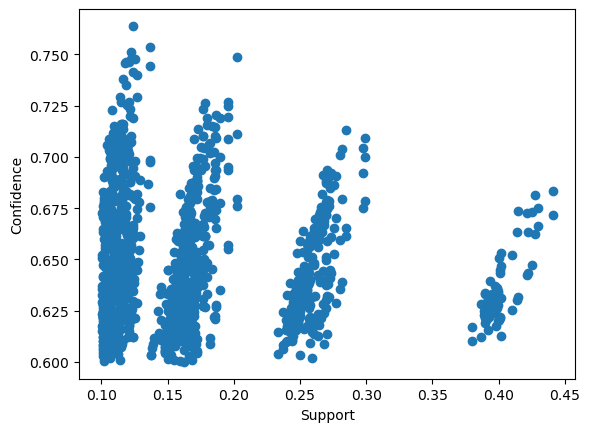

In [8]:
import matplotlib.pyplot as plt

plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()

* Dựa vào bảng kết quả luật kết hợp, ta thấy các quy luật có chỉ số Lift > 1 (Độ nâng) xuất hiện nhiều ở các tập phổ biến liên quan đến Hardness (Độ cứng) và Sulfate. Điều này chứng minh rằng việc hai chỉ số này cùng tăng cao không phải là hiện tượng ngẫu nhiên. Khi một nguồn nước bị cứng, xác suất rất cao nó cũng chứa nhiều gốc Sulfate.
* Từ các luật này, các trạm quan trắc có thể thiết lập hệ thống "Test dây chuyền". Cụ thể, nếu lấy mẫu nhanh phát hiện độ đục vượt mức, hệ thống sẽ tự động kích hoạt cảnh báo đỏ yêu cầu xét nghiệm ngay lập tức các chỉ số hóa học hạng nặng (như pH và Sulfate)